# Data Preprocessing 

In [1]:
import pandas as pd

df = pd.read_csv('CPT.csv', sep=';')

print(df.columns[:10])   # sanity check

Index(['ID', 'Assessment Status', 'Assessment Duration', 'Type', 'LastTrial',
       'Trial1', 'Response1', 'Trial2', 'Response2', 'Trial3'],
      dtype='object')


In [2]:
import pandas as pd

df = pd.read_csv('CPT.csv', sep=';')

# clean weird spaces / hidden characters
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\ufeff', '', regex=False)

print(df.columns[:10])   # check

records = []

trial_cols = [col for col in df.columns if col.startswith('Trial')]

for _, row in df.iterrows():
    subject_id = row['ID']

    for i in range(1, len(trial_cols)+1):
        trial_col = f'Trial{i}'
        resp_col = f'Response{i}'

        rt = row[resp_col]

        records.append({
            'subject': subject_id,
            'trial': i,
            'stimulus': row[trial_col],
            'rt': rt,
            'responded': 0 if rt == -1 else 1
        })

long_df = pd.DataFrame(records)

print(long_df.head())
print(long_df.shape)

Index(['ID', 'Assessment Status', 'Assessment Duration', 'Type', 'LastTrial',
       'Trial1', 'Response1', 'Trial2', 'Response2', 'Trial3'],
      dtype='object')
   subject  trial  stimulus     rt  responded
0      2.0      1      11.0   -1.0          0
1      2.0      2      13.0  469.0          1
2      2.0      3       7.0  343.0          1
3      2.0      4      15.0  275.0          1
4      2.0      5       0.0  295.0          1
(35640, 5)


In [3]:
long_df.to_csv("long_CPT.csv")

In [4]:
long_df

,subject,trial,stimulus,rt,responded
0,2.0,1,11.0,-1.0,0
1,2.0,2,13.0,469.0,1
2,2.0,3,7.0,343.0,1
3,2.0,4,15.0,275.0,1
4,2.0,5,0.0,295.0,1
...,...,...,...,...,...
35635,108.0,356,6.0,282.0,1
35636,108.0,357,2.0,403.0,1
35637,108.0,358,7.0,336.0,1
35638,108.0,359,5.0,320.0,1


In [5]:
# long_df["rt"]=long_df["rt"].replace(-1,pd.NA)

In [6]:
long_df

,subject,trial,stimulus,rt,responded
0,2.0,1,11.0,-1.0,0
1,2.0,2,13.0,469.0,1
2,2.0,3,7.0,343.0,1
3,2.0,4,15.0,275.0,1
4,2.0,5,0.0,295.0,1
...,...,...,...,...,...
35635,108.0,356,6.0,282.0,1
35636,108.0,357,2.0,403.0,1
35637,108.0,358,7.0,336.0,1
35638,108.0,359,5.0,320.0,1


In [7]:
long_df.groupby('stimulus')['responded'].mean()

stimulus
0.0     0.445286
1.0     0.955735
2.0     0.958885
3.0     0.964236
4.0     0.957379
5.0     0.957635
6.0     0.963827
7.0     0.954224
8.0     0.963298
9.0     0.957766
10.0    0.948148
11.0    0.958373
12.0    0.945747
13.0    0.956100
14.0    0.961595
15.0    0.951087
Name: responded, dtype: float64

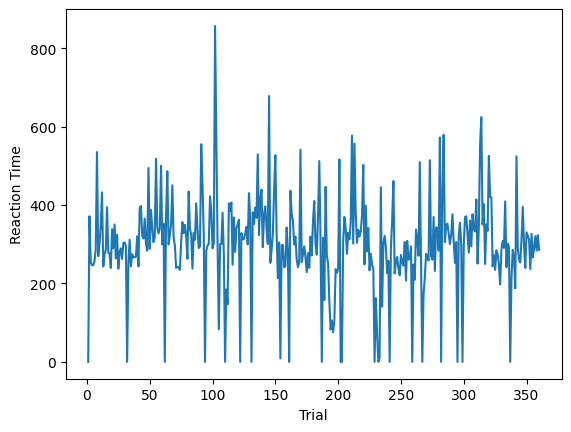

In [8]:
import matplotlib.pyplot as plt

sub = long_df[long_df['subject']==3.]

plt.plot(sub['trial'], sub['rt'])
plt.xlabel("Trial")
plt.ylabel("Reaction Time")
plt.show()

In [9]:
print(long_df['subject'].unique()[:10])

[ 2.  3.  4.  5.  7.  8.  9. 11. 12. 13.]


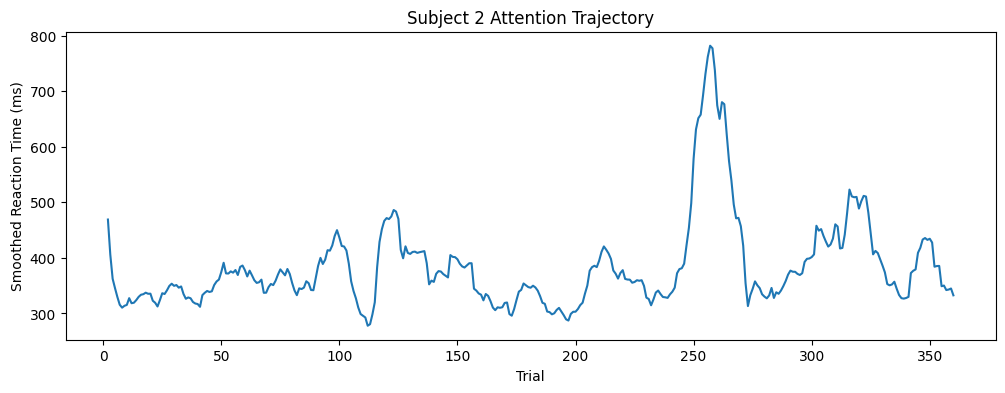

In [10]:
import numpy as np
import matplotlib.pyplot as plt

long_df['rt'] = long_df['rt'].replace([-1, 0], np.nan)

sub = long_df[long_df['subject'] == 2].copy()

# fill missing values for plotting only
sub['rt_clean'] = sub['rt'].interpolate()

sub['smooth_rt'] = sub['rt_clean'].rolling(window=10, min_periods=1).mean()

plt.figure(figsize=(12,4))
plt.plot(sub['trial'], sub['smooth_rt'])
plt.xlabel("Trial")
plt.ylabel("Smoothed Reaction Time (ms)")
plt.title("Subject 2 Attention Trajectory")
plt.show()

In [11]:
long_df.groupby('stimulus')['responded'].mean().sort_values()

stimulus
0.0     0.445286
12.0    0.945747
10.0    0.948148
15.0    0.951087
7.0     0.954224
1.0     0.955735
13.0    0.956100
4.0     0.957379
5.0     0.957635
9.0     0.957766
11.0    0.958373
2.0     0.958885
14.0    0.961595
8.0     0.963298
6.0     0.963827
3.0     0.964236
Name: responded, dtype: float64

In [12]:
long_df['correct'] = (
    ((long_df['stimulus'] != 0) & (long_df['responded'] == 1)) |
    ((long_df['stimulus'] == 0) & (long_df['responded'] == 0))
).astype(int)

In [13]:
long_df.head(50)

,subject,trial,stimulus,rt,responded,correct
0,2.0,1,11.0,NaN,0,0
1,2.0,2,13.0,469.0,1,1
2,2.0,3,7.0,343.0,1,1
3,2.0,4,15.0,275.0,1,1
4,2.0,5,0.0,295.0,1,0
5,2.0,6,12.0,266.0,1,1
6,2.0,7,2.0,246.0,1,1
7,2.0,8,1.0,279.0,1,1
8,2.0,9,9.0,337.0,1,1
9,2.0,10,5.0,328.0,1,1


### Removing non relevent samples

In [14]:
long_df.loc[long_df['rt'] < 150, 'rt'] = np.nan
long_df.loc[long_df['rt'] > 2000, 'rt'] = np.nan

In [15]:
long_df.head(50)

,subject,trial,stimulus,rt,responded,correct
0,2.0,1,11.0,NaN,0,0
1,2.0,2,13.0,469.0,1,1
2,2.0,3,7.0,343.0,1,1
3,2.0,4,15.0,275.0,1,1
4,2.0,5,0.0,295.0,1,0
5,2.0,6,12.0,266.0,1,1
6,2.0,7,2.0,246.0,1,1
7,2.0,8,1.0,279.0,1,1
8,2.0,9,9.0,337.0,1,1
9,2.0,10,5.0,328.0,1,1


In [16]:
def normalize_subject(group):
    rt = group['rt']
    group['attention_proxy'] = 1 - ((rt - rt.min()) / (rt.max() - rt.min()))
    return group

long_df = long_df.groupby('subject').apply(normalize_subject)

C:\Users\abhia\AppData\Local\Temp\ipykernel_5588\630707143.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  long_df = long_df.groupby('subject').apply(normalize_subject)


In [17]:
long_df

subject  trial  stimulus     rt  responded  correct  \
subject                                                              
2.0     0          2.0      1      11.0    NaN          0        0   
        1          2.0      2      13.0  469.0          1        1   
        2          2.0      3       7.0  343.0          1        1   
        3          2.0      4      15.0  275.0          1        1   
        4          2.0      5       0.0  295.0          1        0   
...                ...    ...       ...    ...        ...      ...   
108.0   35635    108.0    356       6.0  282.0          1        1   
        35636    108.0    357       2.0  403.0          1        1   
        35637    108.0    358       7.0  336.0          1        1   
        35638    108.0    359       5.0  320.0          1        1   
        35639    108.0    360       0.0  316.0          1        0   

               attention_proxy  
subject                         
2.0     0                  NaN  
        1             0.719318  
        2             0.862500  
        3             0.939773  
        4             0.917045  
...                        ...  
108.0   35635         0.927765  
        35636         0.859481  
        35637         0.897291  
        35638         0.906321  
        35639         0.908578  

[35640 rows x 7 columns]

In [18]:
long_df['stim_input'] = (long_df['stimulus'] != 0).astype(int)

In [19]:
long_df.head(10)

subject  trial  stimulus     rt  responded  correct  \
subject                                                          
2.0     0      2.0      1      11.0    NaN          0        0   
        1      2.0      2      13.0  469.0          1        1   
        2      2.0      3       7.0  343.0          1        1   
        3      2.0      4      15.0  275.0          1        1   
        4      2.0      5       0.0  295.0          1        0   
        5      2.0      6      12.0  266.0          1        1   
        6      2.0      7       2.0  246.0          1        1   
        7      2.0      8       1.0  279.0          1        1   
        8      2.0      9       9.0  337.0          1        1   
        9      2.0     10       5.0  328.0          1        1   

           attention_proxy  stim_input  
subject                                 
2.0     0              NaN           1  
        1         0.719318           1  
        2         0.862500           1  
        3         0.939773           1  
        4         0.917045           0  
        5         0.950000           1  
        6         0.972727           1  
        7         0.935227           1  
        8         0.869318           1  
        9         0.879545           1

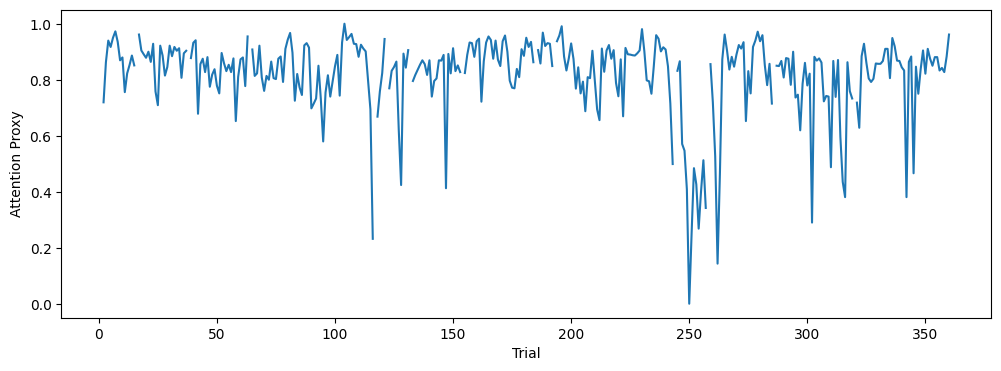

In [20]:
sub = long_df[long_df['subject']==2]

plt.figure(figsize=(12,4))
plt.plot(sub['trial'], sub['attention_proxy'])
plt.xlabel('Trial')
plt.ylabel('Attention Proxy')
plt.show()

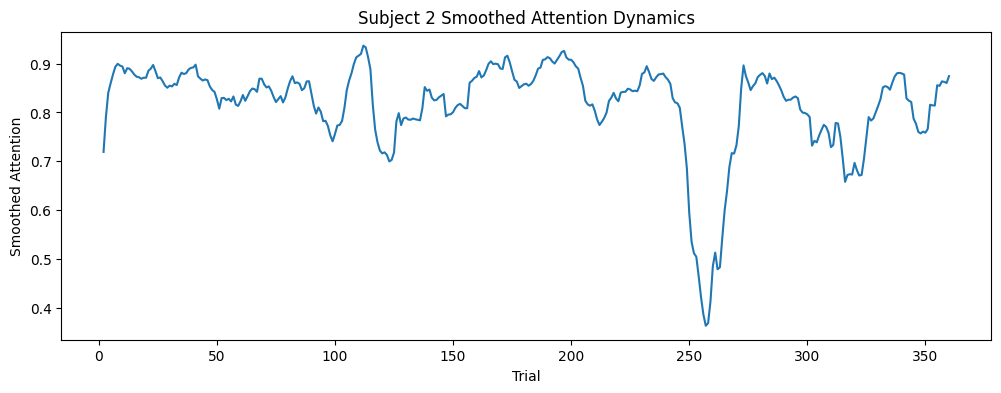

In [21]:
sub = long_df[long_df['subject']==2].copy()

sub['attention_smooth'] = (
    sub['attention_proxy']
    .interpolate()
    .rolling(window=10, min_periods=1)
    .mean()
)

plt.figure(figsize=(12,4))
plt.plot(sub['trial'], sub['attention_smooth'])
plt.xlabel("Trial")
plt.ylabel("Smoothed Attention")
plt.title("Subject 2 Smoothed Attention Dynamics")
plt.show()

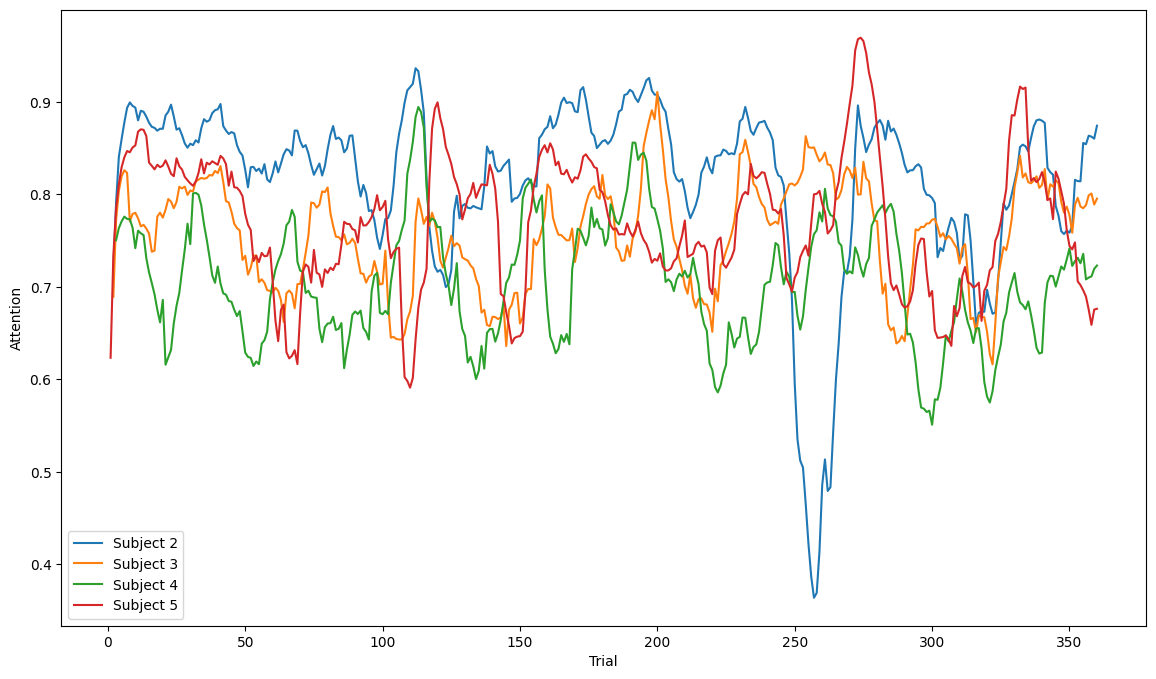

In [22]:
subjects = [2,3,4,5]

plt.figure(figsize=(14,8))

for s in subjects:
    sub = long_df[long_df['subject']==s].copy()
    sub['attention_smooth'] = (
        sub['attention_proxy']
        .interpolate()
        .rolling(10, min_periods=1)
        .mean()
    )
    plt.plot(sub['trial'], sub['attention_smooth'], label=f'Subject {s}')

plt.legend()
plt.xlabel("Trial")
plt.ylabel("Attention")
plt.show()

In [23]:
df_new=pd.read_csv("patient_info.csv")

In [24]:
df_new.columns

Index(['ID;SEX;AGE;ACC;ACC_TIME;ACC_DAYS;HRV;HRV_TIME;HRV_HOURS;CPT_II;ADHD;ADD;BIPOLAR;UNIPOLAR;ANXIETY;SUBSTANCE;OTHER;CT;MDQ_POS;WURS;ASRS;MADRS;HADS_A;HADS_D;MED;MED_Antidepr;MED_Moodstab;MED_Antipsych;MED_Anxiety_Benzo;MED_Sleep;MED_Analgesics_Opioids;MED_Stimulants;filter_$'], dtype='object')

In [25]:
df_new = pd.read_csv('patient_info.csv', sep=';')
df_new.columns = df_new.columns.str.strip()
df_new.columns = df_new.columns.str.replace('\ufeff', '', regex=False)

In [26]:
print(df_new[['ID','ADHD','AGE','SEX']])

      ID  ADHD  AGE  SEX
0      1     1    3    0
1      2     1    4    0
2      3     1    2    1
3      4     1    3    1
4      5     1    1    1
..   ...   ...  ...  ...
98   103     0    4    1
99   104     0    2    0
100  105     0    4    1
101  106     0    3    0
102  108     1    3    1

[103 rows x 4 columns]


In [28]:
long_df = long_df.droplevel("subject", axis=0)


In [29]:
long_df = long_df.merge(
    df_new[['ID','ADHD','AGE','SEX']],
    left_on='subject',
    right_on='ID',
    how='left'
)

print(long_df.head())

   subject  trial  stimulus     rt  responded  correct  attention_proxy  \
0      2.0      1      11.0    NaN          0        0              NaN   
1      2.0      2      13.0  469.0          1        1         0.719318   
2      2.0      3       7.0  343.0          1        1         0.862500   
3      2.0      4      15.0  275.0          1        1         0.939773   
4      2.0      5       0.0  295.0          1        0         0.917045   

   stim_input  ID  ADHD  AGE  SEX  
0           1   2     1    4    0  
1           1   2     1    4    0  
2           1   2     1    4    0  
3           1   2     1    4    0  
4           0   2     1    4    0  


In [ ]:
long_df

,subject,trial,stimulus,rt,responded,correct,attention_proxy,stim_input,ID_x,ADHD_x,AGE_x,SEX_x,ID_y,ADHD_y,AGE_y,SEX_y
0,2.0,1,11.0,NaN,0,0,NaN,1,2,1,4,0,2,1,4,0
1,2.0,2,13.0,469.0,1,1,0.719318,1,2,1,4,0,2,1,4,0
2,2.0,3,7.0,343.0,1,1,0.862500,1,2,1,4,0,2,1,4,0
3,2.0,4,15.0,275.0,1,1,0.939773,1,2,1,4,0,2,1,4,0
4,2.0,5,0.0,295.0,1,0,0.917045,0,2,1,4,0,2,1,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35635,108.0,356,6.0,282.0,1,1,0.927765,1,108,1,3,1,108,1,3,1
35636,108.0,357,2.0,403.0,1,1,0.859481,1,108,1,3,1,108,1,3,1
35637,108.0,358,7.0,336.0,1,1,0.897291,1,108,1,3,1,108,1,3,1
35638,108.0,359,5.0,320.0,1,1,0.906321,1,108,1,3,1,108,1,3,1


In [30]:
print(long_df[['subject','ADHD']].drop_duplicates()['ADHD'].value_counts())

ADHD
1    50
0    49
Name: count, dtype: int64
